# Phonon baths on the shell grid (EI_bins)
Same checks as phonon_bath_vis.ipynb, for the shell solver: dispersion and
coupling, spectral line and its gamma -> 0 limit, shell averaged |G|^2,
energy and Bose factors, source rates on the BZ and along the shells,
detailed balance, T*(eps) and the NESS occupations.

In [1]:
import os
from pathlib import Path

import numpy as np
import yaml
import colormaps as cmaps
from matplotlib.colors import LogNorm, Normalize

import EI_bins as eb
from EI_bins.kernel import (cells, coh2, delta_brk, delta_geo, rates, spec_brk,
                            spec_geo, spec_line)
from utils.cosmetics import SET1_LIST, apply_plt_style
from utils.logger import logger
from utils.plotting_utils import Plotter, add_legend, color_map, format_ax

ROOT = Path(os.environ.get("EI_ROOT", "/home/kzeleznikar/IJS-F1/Koda/EI_baths"))
CFG = ROOT / "config" / "config_phonons.yaml"

apply_plt_style()
pt = Plotter(show=True, close=False)
SOLVE = eb.solve_ness          # eb.solve_ness_jax on the GPU

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [2]:
with CFG.open("r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

bd = eb.Band(**cfg["model"]["band"]["pars"])
p = eb.MF(**cfg["model"]["mean_field"])
bq = dict(cfg["open_system"]["bath"]["pars"])   # disp, w0, cs, ktf, ew (gamma), c
# bq.update(disp="acoustic", cs=0.6, ew=0.0)    # try other dispersions / widths

In [3]:
# equilibrium scales on a fine shell grid, Tc by bisection on the ordered branch
ref = eb.make_shells(131)
s0 = eb.solve_eq(ref, bd, p, 1.0e-3, 1.0, -0.6)
d0, m0 = s0.d, s0.m
lo, hi = 0.05, 2.0
for _ in range(40):
    t = 0.5 * (lo + hi)
    e = eb.solve_eq(ref, bd, p, t, 0.5 * d0, m0)
    lo, hi = (t, hi) if (e.ok and e.d > 1.0e-4) else (lo, t)
tc = 0.5 * (lo + hi)

logger.info("Delta_0 = %.8f", d0)
logger.info("m_0 = %.8f", m0)
logger.info("T_c = %.8f", tc)

[09:39:55] [INFO    ] Delta_0 = 1.00005410
[09:39:55] [INFO    ] m_0 = -0.68433759
[09:39:55] [INFO    ] T_c = 0.53523672


In [4]:
t1n, t2n = 1.6, 0.2
t1, t2 = t1n * tc, t2n * tc

sh = eb.make_shells(eb.auto_ns(bd, min(d0, tc, bq.get("w0", 1.0))))
bs = (eb.from_cfg(t1, bq, name="bath_1"), eb.from_cfg(t2, bq, name="bath_2"))
kn = eb.kernels(sh, bd, bs, cache=ROOT / "kernels")   # one Kern per bath
so = SOLVE(sh, bd, p, bs, A=kn)
cl = cells(sh, bd, p, so.d, so.m)

b, k = bs[0], kn[0]
print(b.disp, b.w0, b.cs, b.lam, b.gam, "| ns =", sh.ns, "| bins =", k.om.size)
logger.info("NESS: Delta = %.6f, m = %.6f, %s, ok = %s, stable = %s",
            so.d, so.m, so.branch, so.ok, so.stable)

/home/kzeleznikar/IJS-F1/Koda/src/EI_bins/solve.py:605: UserWarning: ordered branch lost at lam = 0.8125, returning the normal branch
  warnings.warn(f"ordered branch lost at lam = {hist['fold']:.4g}, "


acoustic 2.2 1.6 0.2 0.0 | ns = 61 | bins = 55


[09:40:45] [INFO    ] NESS: Delta = 0.000000, m = -0.721650, normal, ok = True, stable = True


In [5]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Define the range of gamma values to sweep over
# gamma_values = np.linspace(0.0, 1.0, 5) 
# delta_results = []

# # Generate the shared shell setup once (assuming w0 doesn't change with gamma)
# sh = eb.make_shells(eb.auto_ns(bd, min(d0, tc, bq.get("w0", 1.0))))

# for gam in gamma_values:
#     # Override the yaml setting for gam
#     bq["gam"] = float(gam)
    
#     # Re-initialize the baths with the updated parameters
#     bs = (eb.from_cfg(t1, bq, name="bath_1"), eb.from_cfg(t2, bq, name="bath_2"))
    
#     # Recompute kernels for the updated baths
#     kn = eb.kernels(sh, bd, bs, cache=ROOT / "kernels")
    
#     # Solve for the steady state
#     so = SOLVE(sh, bd, p, bs, A=kn)
    
#     # Store the resulting Delta
#     delta_results.append(so.d)
    
#     logger.info(f"Solved for gam = {gam:.3f} | Delta = {so.d:.6f}")


In [6]:

# # Plot Delta vs gamma
# plt.figure(figsize=(8, 5))
# plt.plot(gamma_values, delta_results, marker='o', markersize=4, linestyle='-', color='b')
# plt.xlabel(r'$\gamma$')
# plt.ylabel(r'$\Delta$')
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

## Dispersion and coupling
Left: w_q over the BZ. Middle: |g(q)|^2 / amp = q^2 / (w_q (q^2 + lam^2)^2)
for |q| <= qd. Right: coupling weight of every frequency bin of the pair
kernel, sum_IJ A[m, I, J] (a single bin for constant dispersion).

findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


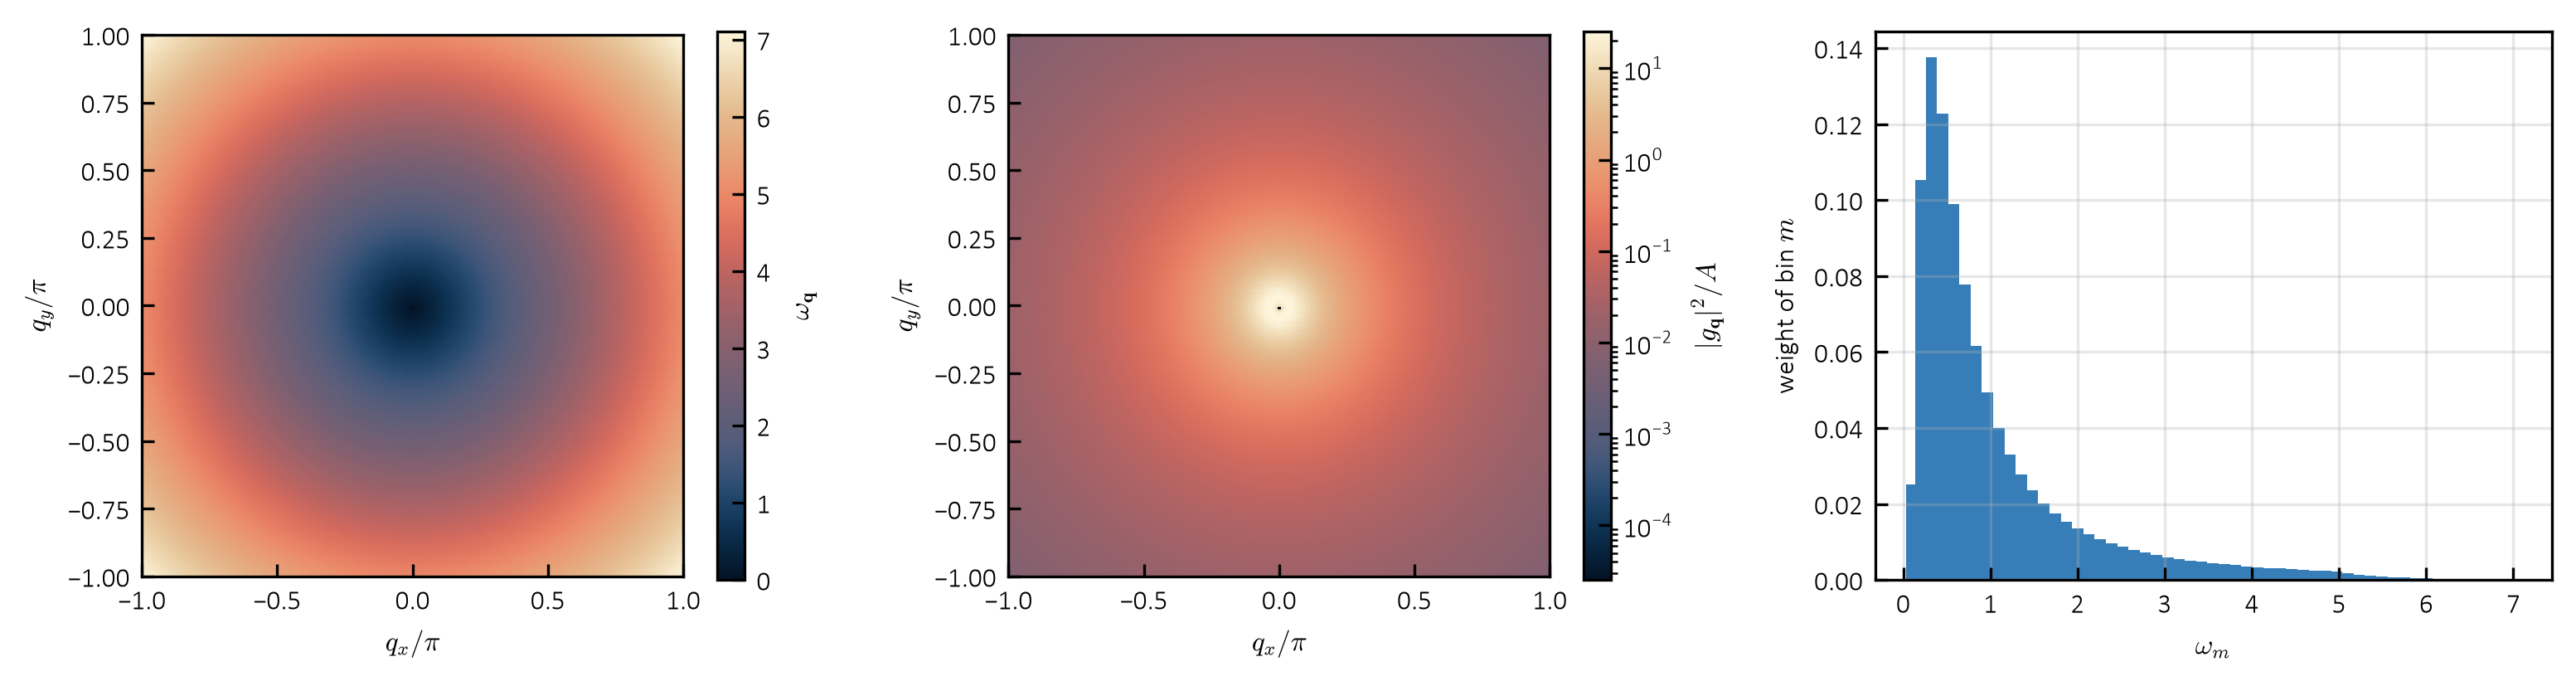

In [7]:
q = np.linspace(-np.pi, np.pi, 201)
qx, qy = np.meshgrid(q, q, indexing="ij")
qm = np.hypot(qx, qy)
wq = eb.omega(b, qm)
gq = np.where((qm > 0.0) & (qm <= b.qd),
              qm**2 / (np.maximum(wq, 1e-300) * (qm**2 + b.lam**2) ** 2), np.nan)
aw = k.A.sum(axis=(1, 2))

with pt.figure(shape=(1, 3), h=0.8, w=3.0) as fg:
    a0, a1, a2 = fg.ax
    im = color_map(a0, q / np.pi, q / np.pi, wq.T)
    fg.colorbar(im, r"$\omega_\mathbf{q}$", ax=a0)
    im = color_map(a1, q / np.pi, q / np.pi, np.ma.masked_invalid(gq.T),
                   norm=LogNorm(vmin=np.nanmax(gq) * 1e-6, vmax=np.nanmax(gq)))
    fg.colorbar(im, r"$|g_\mathbf{q}|^2/A$", ax=a1)
    for a in (a0, a1):
        format_ax(a, x=q / np.pi, xlabel=r"$q_x/\pi$", ylabel=r"$q_y/\pi$", grid=False)
        a.set_aspect("equal")
    a2.bar(k.om, aw / aw.sum(), width=max(k.dw, 0.02), color=SET1_LIST[1])
    format_ax(a2, xlabel=r"$\omega_m$", ylabel=r"weight of bin $m$")

## Spectral line and the gamma -> 0 limit
Top: damped oscillator line B(e; w0, gamma), normalized on e > 0; gamma = 0
is the delta line at w0. Bottom: the bracket of one cell pair (source above
destination by x), (1 + N) (B * L)(x) + N (B * L)(-x) with the overlap kernel
L of the pair. As gamma -> 0 it converges to the sharp line bracket.

findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


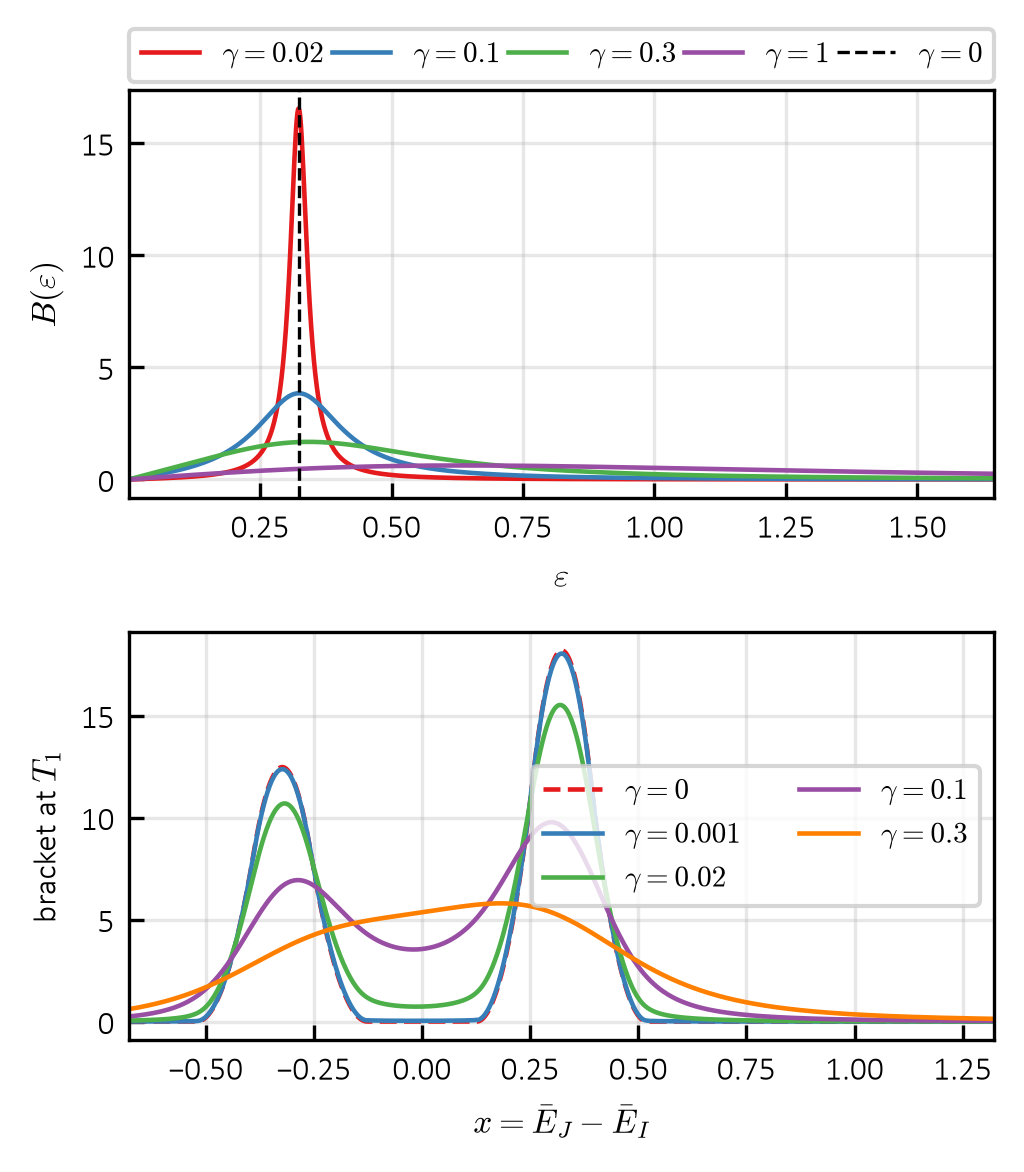

In [8]:
w0 = float(k.om[np.argmax(aw)])            # dominant frequency
eg = np.linspace(1.0e-3, 2.0 * w0 + 1.0, 1200)
gs = (0.02, 0.1, 0.3, 1.0)

hw = cl.hw.reshape(-1)
ha = hb = float(np.median(hw))             # a typical cell pair
cmin = max(float(hw.max()), k.dw)
xs = np.linspace(w0 - 1.0, w0 + 1.0, 801)


def bracket_1d(x, gam, t):
    """(1 + N) (B * L)(x) + N (B * L)(-x) for one pair, scanned over x."""
    a, c = np.full_like(x, ha), np.full_like(x, hb)
    if gam > 0.0:
        up, dn = (spec_geo(np, s * x, a, c, cmin, w0, gam, t) for s in (1.0, -1.0))
        n1, n0 = (np.where(t > 0, 1.0 / np.expm1(np.maximum(g[0], 1e-200) / t), 0.0)
                  for g in (up, dn))
        return np.sum(up[1] * (1.0 + n1), -1) + np.sum(dn[1] * n0, -1)
    lu, ld = (delta_geo(np, s * x, a, c, cmin, w0) for s in (1.0, -1.0))
    n = 1.0 / np.expm1(w0 / t) if t > 0 else 0.0
    return (1.0 + n) * lu + n * ld


with pt.figure(shape=(2, 1), h=1.2) as fg:
    a = fg.ax[0]
    for i, g in enumerate(gs):
        a.plot(eg, spec_line(np, eg, w0, g), color=SET1_LIST[i], lw=1.1,
               label=rf"$\gamma={g:g}$")
    a.axvline(w0, color="k", ls="--", lw=0.8, label=r"$\gamma=0$")
    format_ax(a, x=eg, xlabel=r"$\varepsilon$", ylabel=r"$B(\varepsilon)$")
    add_legend(a, top=True, ncol=5, fontsize=7)

    a = fg.ax[1]
    for i, g in enumerate((0.0, 1e-3, 0.02, 0.1, 0.3)):
        a.plot(xs, bracket_1d(xs, g, t1), color=SET1_LIST[i], lw=1.1,
               ls="--" if g == 0 else "-", label=rf"$\gamma={g:g}$")
    format_ax(a, x=xs, xlabel=r"$x = \bar E_J - \bar E_I$",
              ylabel=r"bracket at $T_1$")
    add_legend(a, ncol=2, fontsize=7)
    fg.layout((0, 0, 1, 0.95))

## Source cell and shell averaged factors
The source is the alpha cell at the gap edge (lowest E_alpha), i.e. the
whole shell of states with that s. Shell quantities are drawn on the BZ by
giving every k the value of its cell. For a destination (nu, I):
- 2 pi |G|^2 = 2 pi amp |C_IJ|^2 sum_m A_m[I, J] / (W_I W_J), the pair
  averaged coupling (C = U_I^T c U_J),
- line factor = pair kernel weighted sum_m A_m [L_m(x) + L_m(-x)] / sum_m A_m
  with x = E_J - E_I (no thermal factors, the analogue of L(|dE|; w_q)),
- Bose factor = rate / (2 pi amp |C|^2 A line), summed over the baths
  (sharp lines: 1 + N for emission, N for absorption, per bath).
For gamma = 0 only cells within the overlap kernel of E_mu(J0) -+ w_m are
coupled, all other cells are blank (zero) on the log colour scales.

In [9]:
mu = 0                                     # source branch: 0 = alpha, 1 = beta
j0 = int(np.argmin(cl.e[mu]))              # gap edge cell
jf = mu * sh.ns + j0                       # flat source index
bl = (r"\alpha", r"\beta")

nk = 121
kk = np.linspace(-np.pi, np.pi, nk, endpoint=False)
lab = sh.cell(np.cos(kk)[:, None] + np.cos(kk)[None, :])
w2 = np.tile(sh.w, 2)

ef = cl.e.reshape(-1)
x = ef[None, :] - ef[:, None]               # source minus destination
ha2, hb2 = hw[:, None], hw[None, :]
cmin = max(float(hw.max()), k.dw)
m2 = (cl.ma, cl.mb)


def bz(z):
    """(2 ns) cell values -> (2, nk, nk) on the BZ."""
    return np.asarray(z).reshape(2, sh.ns)[:, lab]


tlo = min([bt.t for bt in bs if bt.t > 0], default=np.inf)   # as in rates()


def factors(bt, kt):
    """Pair kernel sum, line factor and bracket (bins summed) of one bath."""
    at, lin, brk = np.zeros_like(x), np.zeros_like(x), np.zeros_like(x)
    cm = max(float(hw.max()), kt.dw)
    for m in range(kt.om.size):
        am = np.tile(kt.A[m], (2, 2))
        if bt.gam > 0:
            geo = spec_geo(np, x, ha2, hb2, cm, kt.om[m], bt.gam, tlo)
            s1 = geo[1].sum(-1)
            lin += am * (s1 + s1.T)
            brk += am * spec_brk(np, geo, bt.t)
        else:
            le = delta_geo(np, x, ha2, hb2, cm, kt.om[m])
            lin += am * (le + le.T)
            brk += am * delta_brk(np, le, kt.om[m], bt.t)
        at += am
    cc = np.block([[coh2(m2[i], m2[j], bt.cm) for j in range(2)] for i in range(2)])
    p = 2.0 * np.pi * bt.amp * cc * brk
    up = p.T * np.exp(np.minimum(x, 0.0) / bt.t) if bt.t > 0 else 0.0 * p
    kb = np.where(x >= 0.0, p, up)
    np.fill_diagonal(kb, 0.0)
    return cc, at, lin, kb


fs = [factors(bt, kt) for bt, kt in zip(bs, kn)]
cc, at, lin = fs[0][:3]
kt = sum(f[3] for f in fs)                  # total pair flux coefficients

g2 = 2.0 * np.pi * b.amp * cc[:, jf] * at[:, jf] / (w2 * w2[jf])
lz = np.where(at[:, jf] > 0, lin[:, jf] / np.where(at[:, jf] > 0, at[:, jf], 1.0), np.nan)
den = 2.0 * np.pi * b.amp * cc[:, jf] * lin[:, jf]
fb = np.where(den > 1e-300 * den.max(), kt[:, jf] / np.where(den > 0, den, 1.0), np.nan)
gr = kt[:, jf] / (w2 * w2[jf])              # rate per destination state
for z in (g2, lz, fb, gr):
    z[jf] = np.nan                          # self term is excluded

er = np.max(np.abs(kt - rates(cl, bs, kn))) / np.max(np.abs(kt))
print(f"max rel. diff, factors vs rates(): {er:.2e}")

max rel. diff, factors vs rates(): 0.00e+00


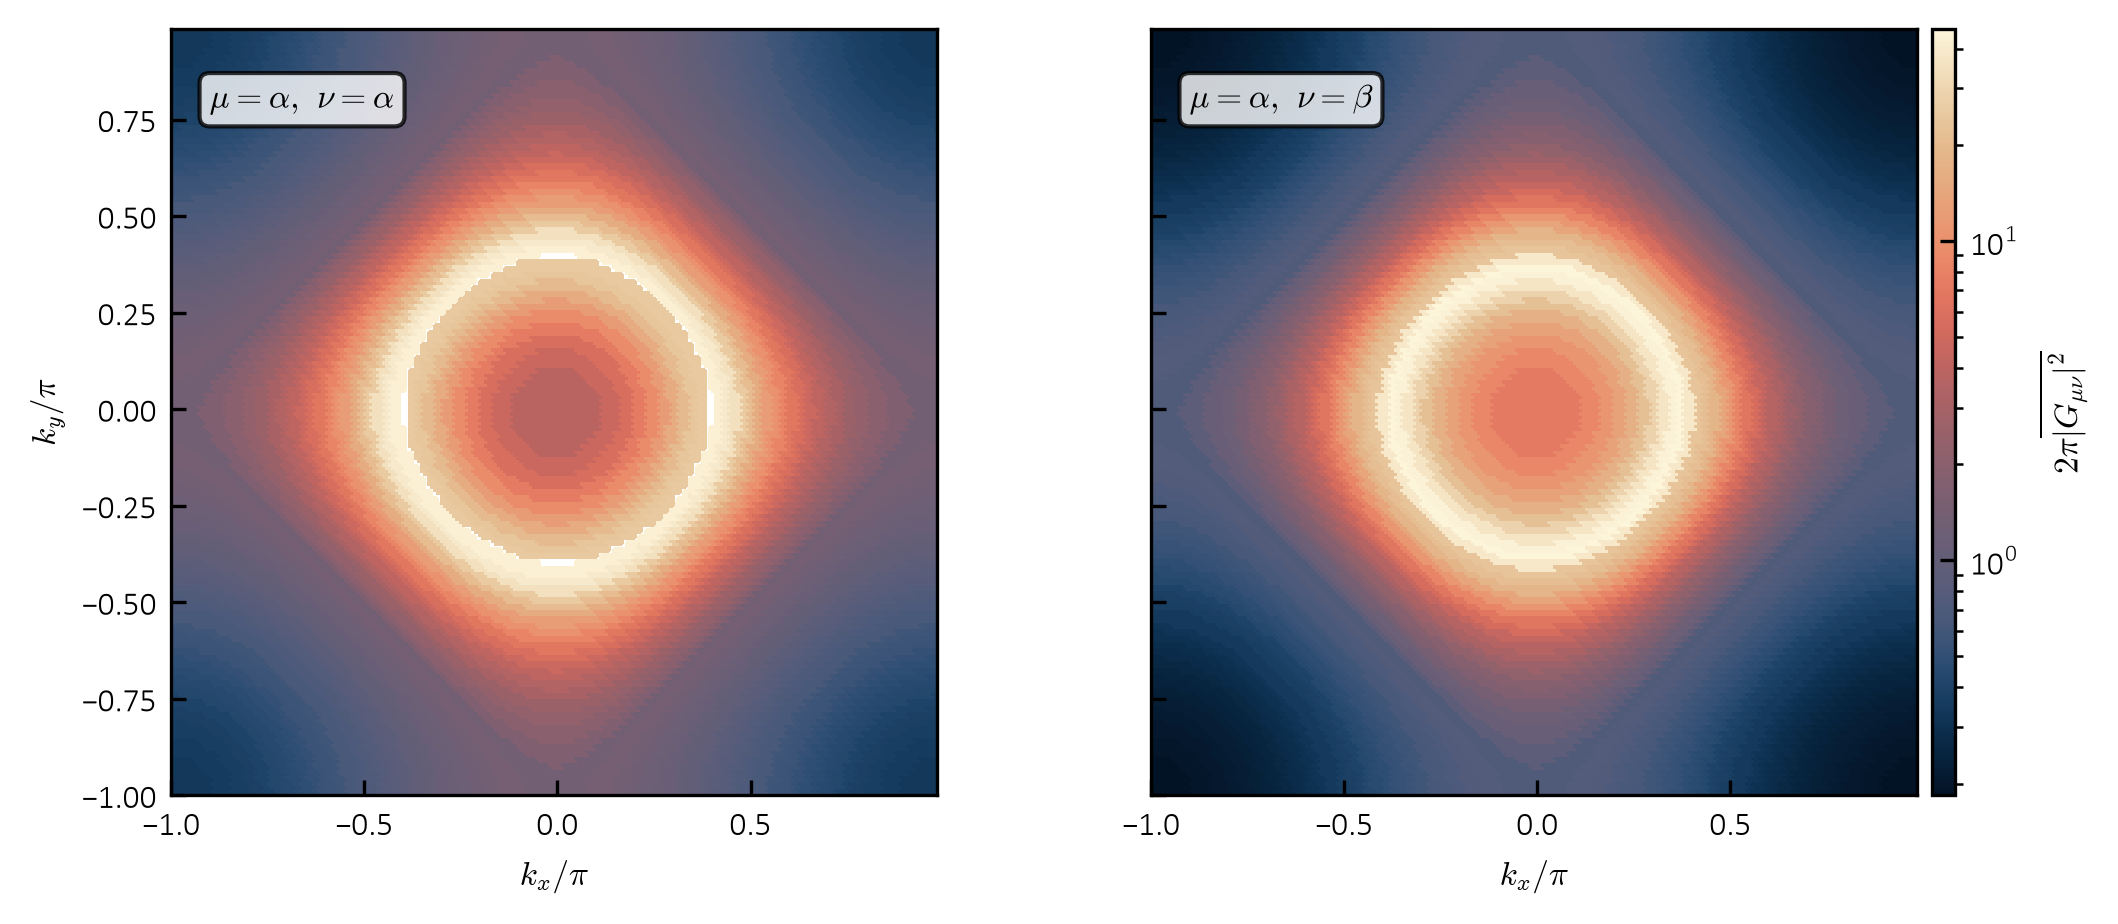

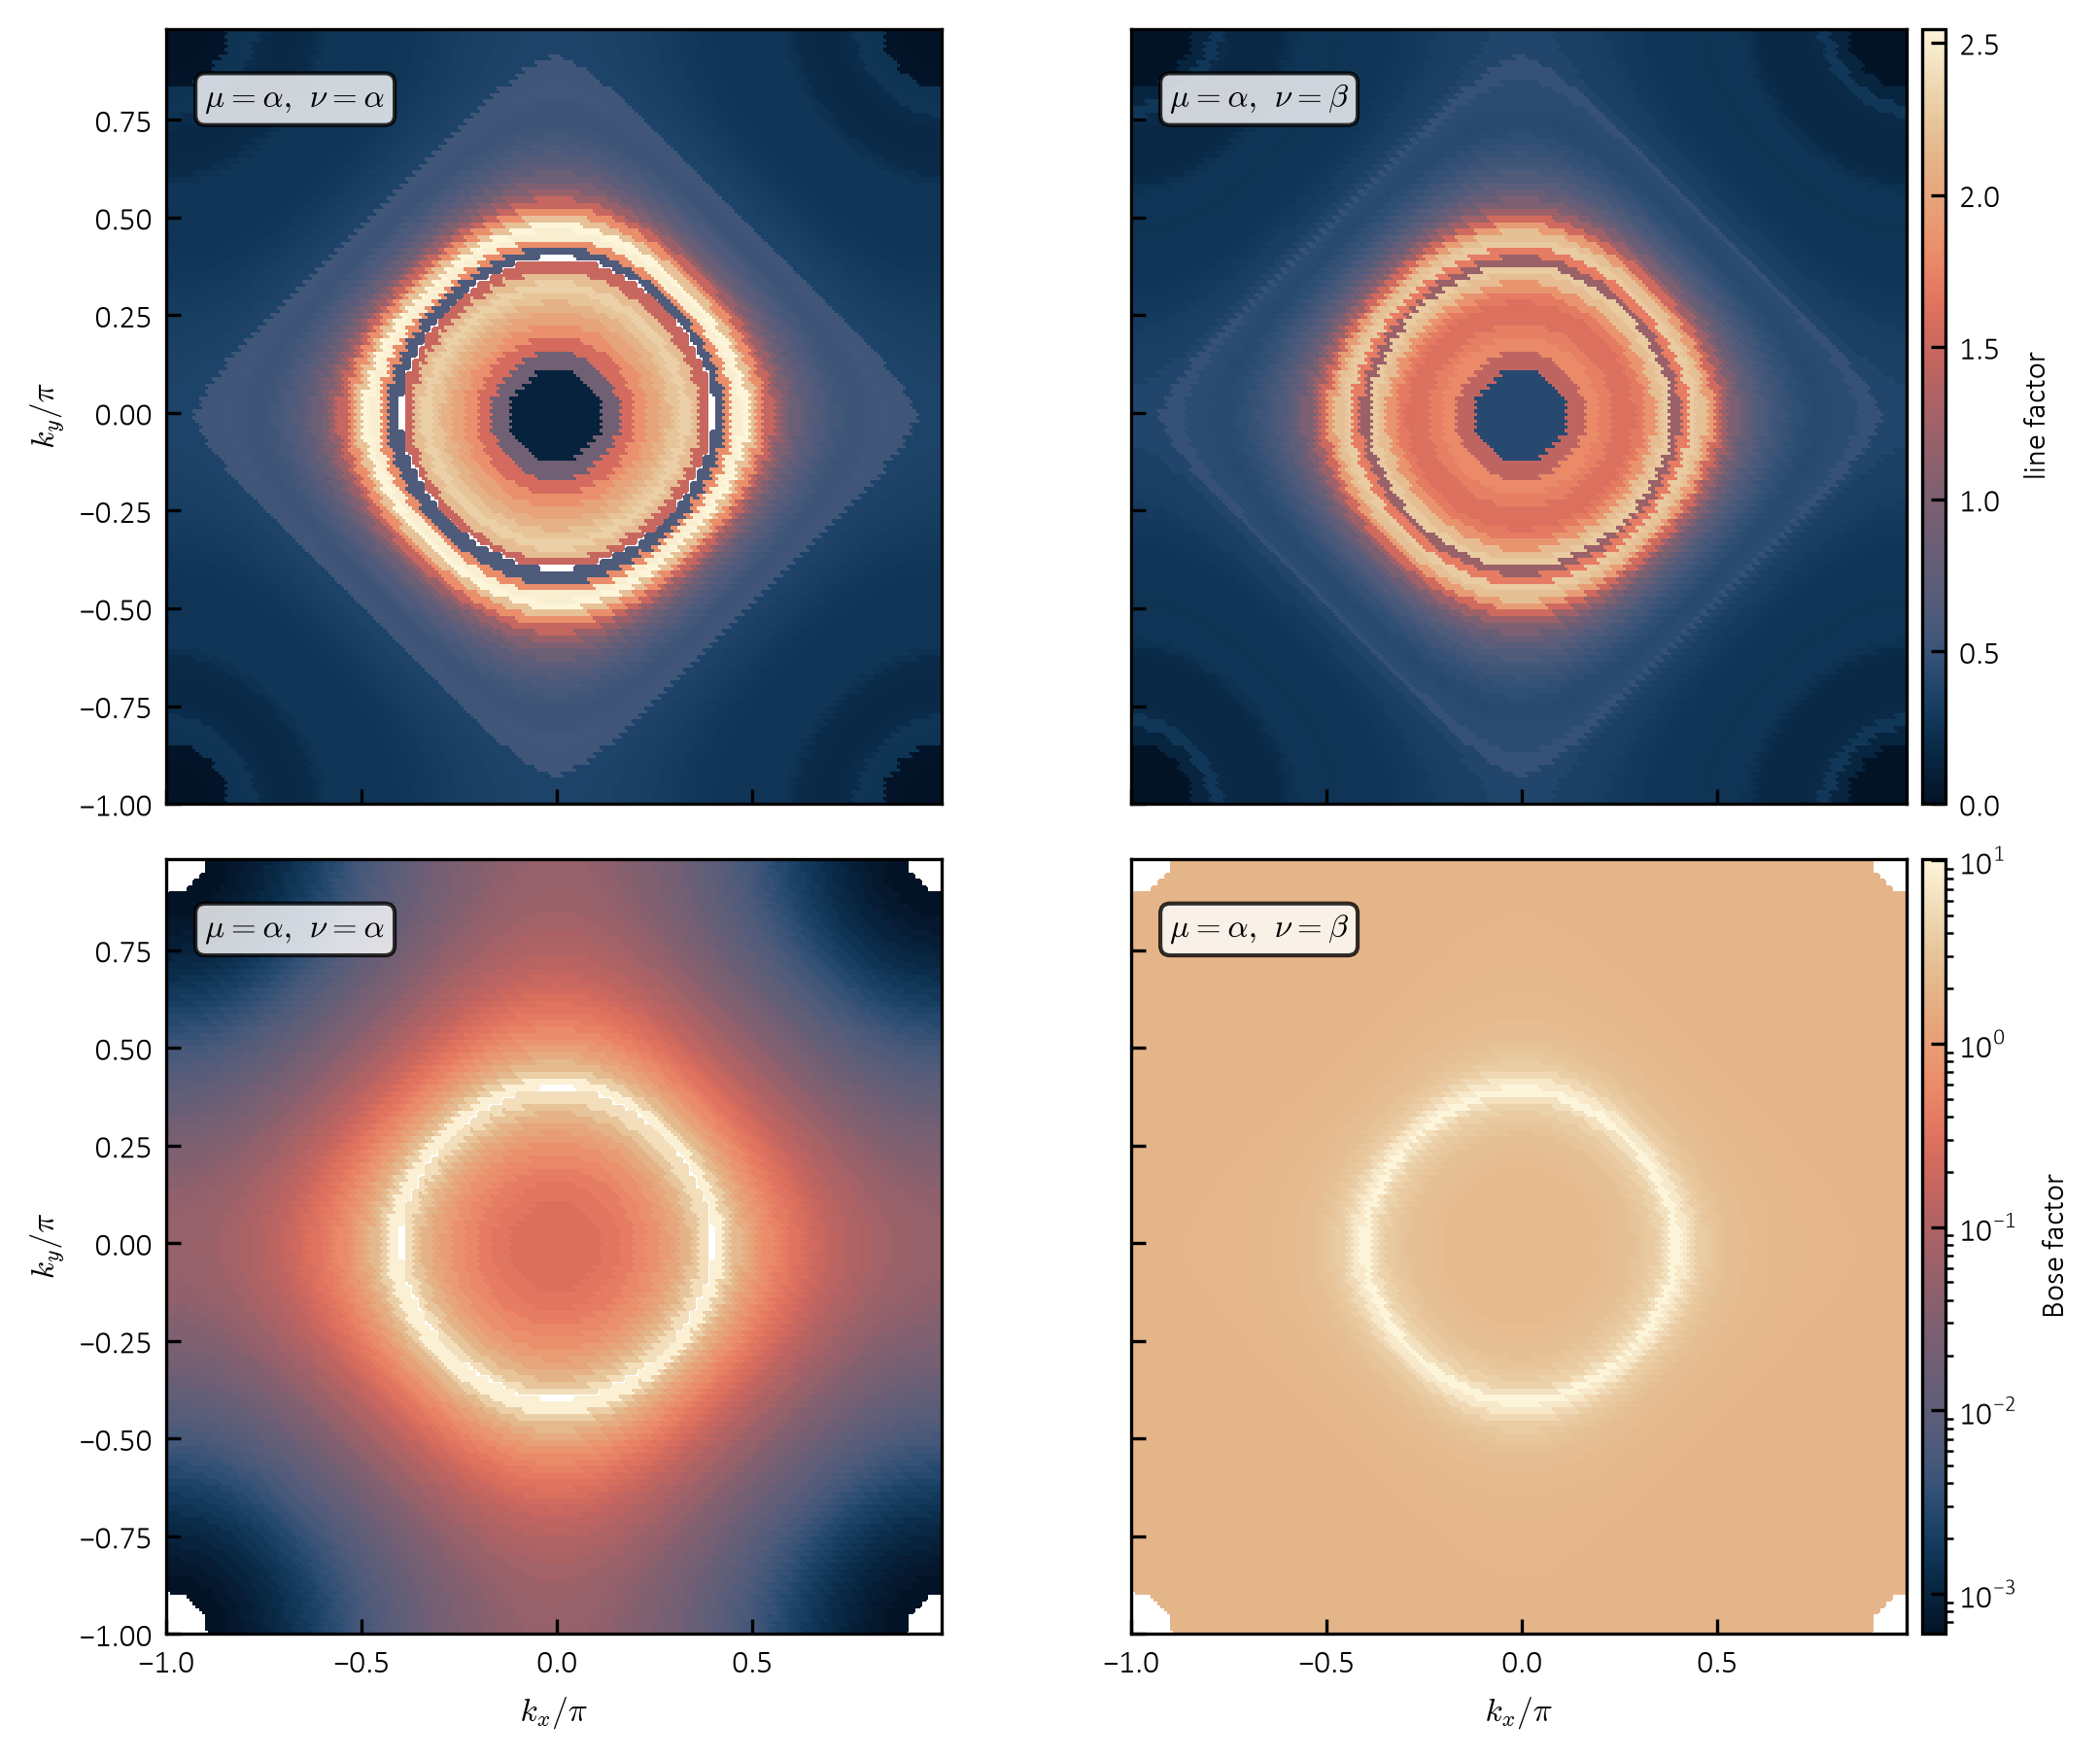

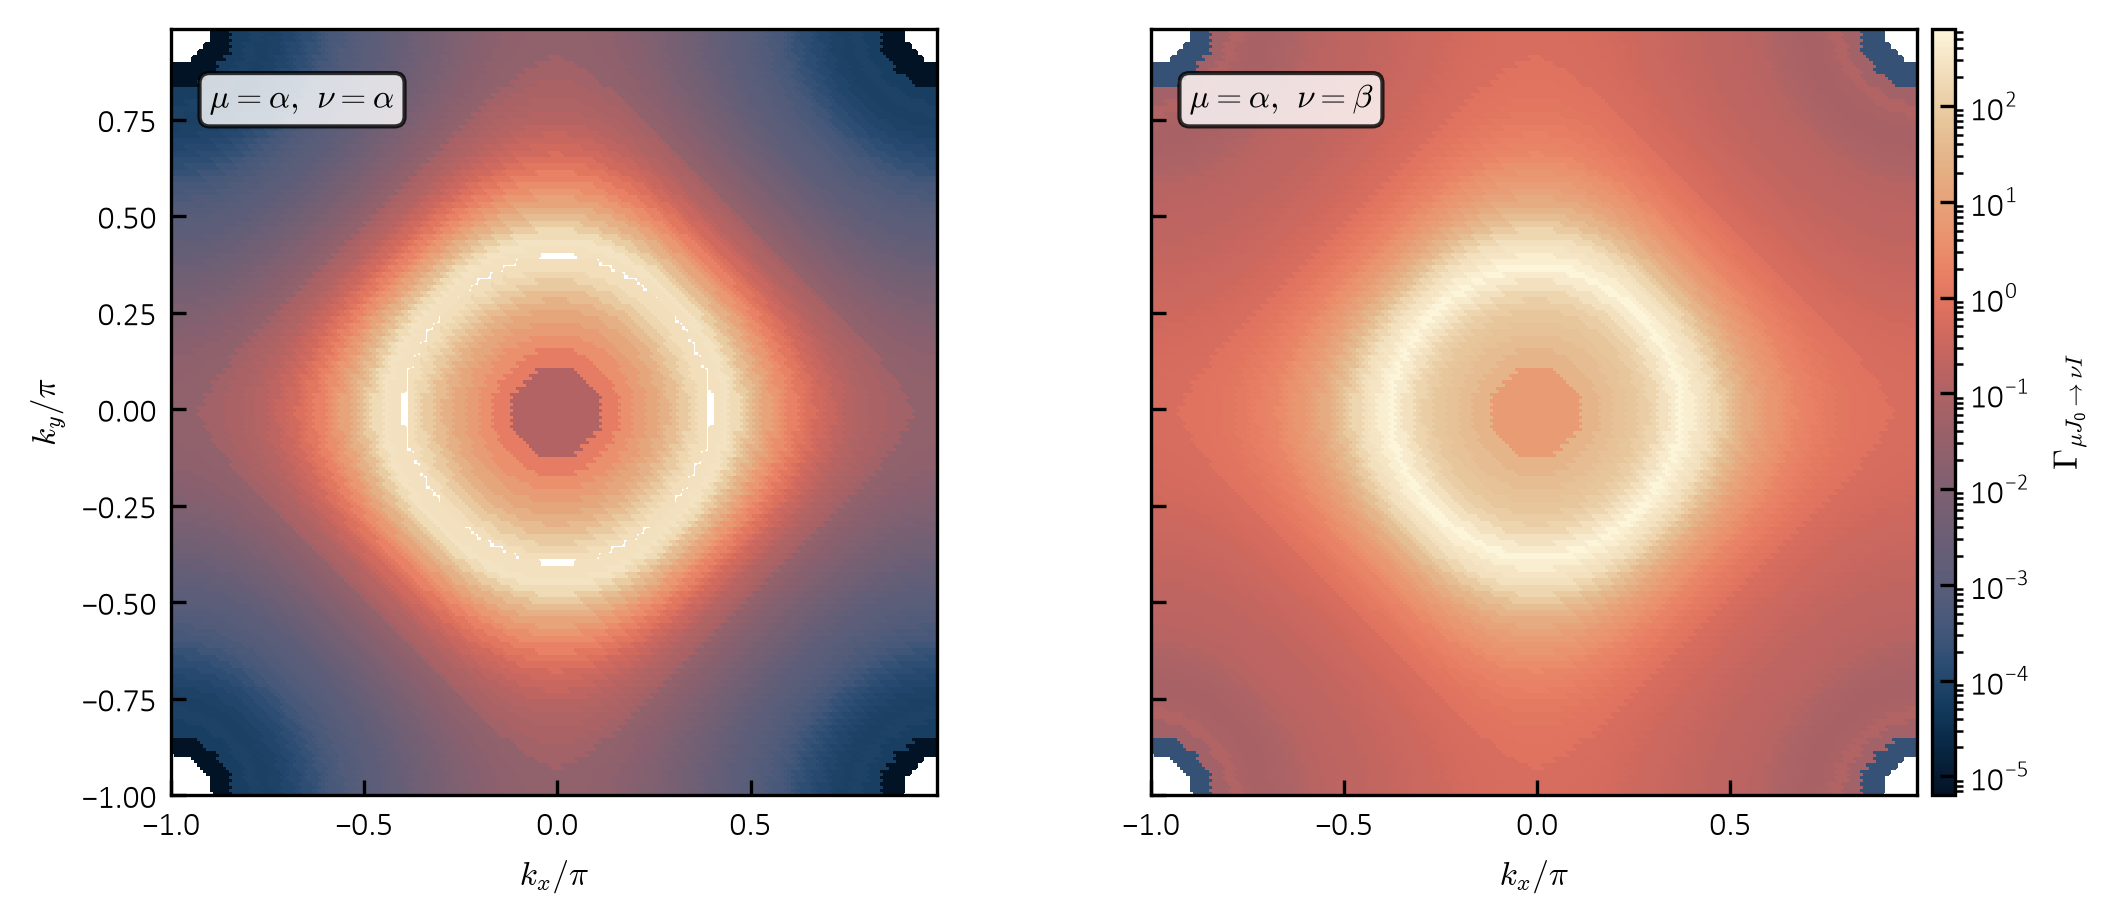

In [10]:
def lnorm(z, dr=1.0e-8):
    """Log norm over positive finite values, floored at dr * max."""
    zp = z[np.isfinite(z) & (z > 0.0)]
    return LogNorm(vmin=max(zp.min(), dr * zp.max()), vmax=zp.max())

def bz_pair(fg, ax, z, norm, lab_):
    """Draw the nu = alpha, beta panels of a (2 ns) field over the BZ."""
    zz = bz(z)
    for nu, a in enumerate(ax):
        im = color_map(a, kk / np.pi, kk / np.pi, np.ma.masked_invalid(zz[nu].T), norm=norm)
        a.text(0.05, 0.93, rf"$\mu={bl[mu]},\ \nu={bl[nu]}$", transform=a.transAxes,
               ha="left", va="top",
               bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))
        format_ax(a, x=kk / np.pi, grid=False)
        a.set_aspect("equal")
    fg.colorbar(im, lab_, ax=ax[-1], external=True)


with pt.figure(shape=(1, 2), h=0.85, w=2.0, sharex=True, sharey=True) as fg:
    bz_pair(fg, fg.ax, g2, lnorm(g2), r"$2\pi\overline{|G_{\mu\nu}|^2}$")
    for a in fg.ax:
        a.set_xlabel(r"$k_x/\pi$")
    fg.ax[0].set_ylabel(r"$k_y/\pi$")

with pt.figure(shape=(2, 2), h=1.7, w=2.0, sharex=True, sharey=True) as fg:
    bz_pair(fg, fg.ax[0], lz, Normalize(0.0, np.nanmax(lz)), r"line factor")
    bz_pair(fg, fg.ax[1], fb, lnorm(fb), r"Bose factor")
    for a in fg.ax[1]:
        a.set_xlabel(r"$k_x/\pi$")
    for a in fg.ax[:, 0]:
        a.set_ylabel(r"$k_y/\pi$")

with pt.figure(shape=(1, 2), h=0.85, w=2.0, sharex=True, sharey=True) as fg:
    bz_pair(fg, fg.ax, gr, lnorm(gr), r"$\Gamma_{\mu J_0\to\nu I}$")
    for a in fg.ax:
        a.set_xlabel(r"$k_x/\pi$")
    fg.ax[0].set_ylabel(r"$k_y/\pi$")

## Along the shells
The shell variable s = cos kx + cos ky plays the role of the k path.
Top: destination energies relative to the source, E_nu(s) - E_mu(J0),
coloured by the rate, with the phonon lines -+ w_m (bands: -+ gamma).
Rows: the factors above; their product is the rate in the last row.

/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:509: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.tight_layout(rect=self.rect)
findfont: Failed to find font weight normal, now using 300.
findfont: Failed to find font weight normal, now using 300.


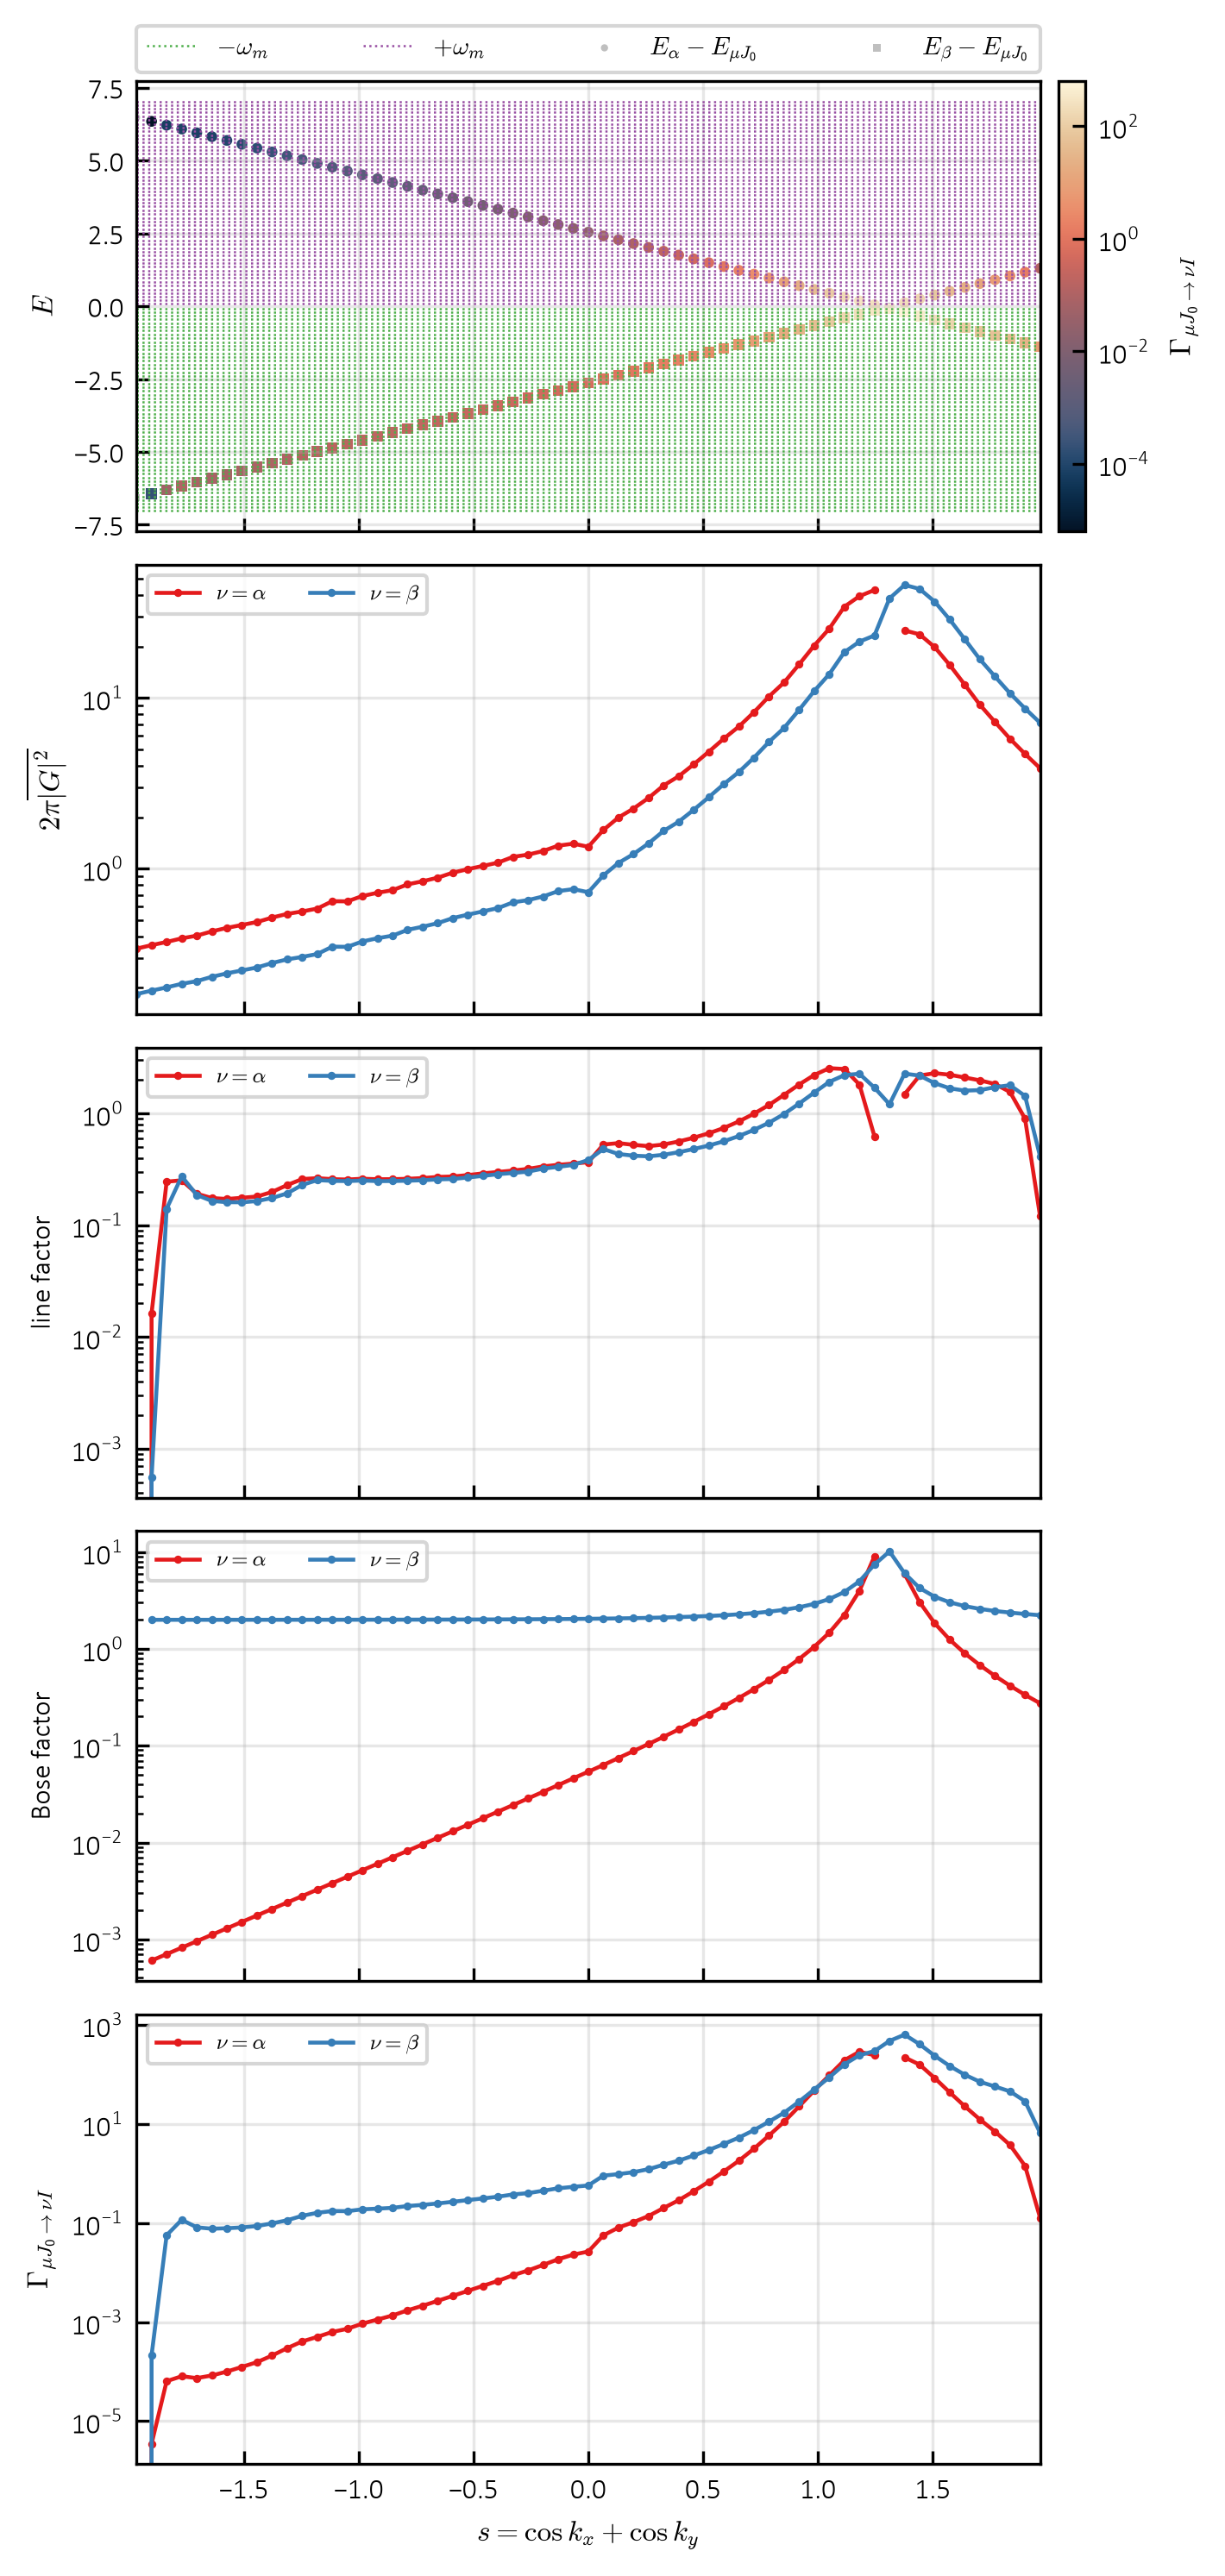

In [11]:
sc = sh.sc
ep = cl.e - cl.e[mu, j0]
yg, yl, yf, yr = (np.asarray(z).reshape(2, sh.ns) for z in (g2, lz, fb, gr))
rows = ((yg, r"$2\pi\overline{|G|^2}$"), (yl, r"line factor"),
        (yf, r"Bose factor"), (yr, r"$\Gamma_{\mu J_0\to\nu I}$"))
cn = lnorm(gr)

with pt.figure(shape=(5, 1), h=3.0, w=1.2, sharex=True) as fg:
    a = fg.ax[0]
    for s, c_ in ((1.0, SET1_LIST[2]), (-1.0, SET1_LIST[3])):
        for m in range(k.om.size):
            a.axhline(-s * k.om[m], color=c_, ls=":", lw=0.6 if k.om.size > 1 else 1.0,
                      label=(rf"${'-' if s > 0 else '+'}\omega_m$" if m == 0 else None))
            if b.gam > 0:
                a.axhspan(-s * k.om[m] - b.gam, -s * k.om[m] + b.gam, color=c_,
                          alpha=0.15 / k.om.size, lw=0)
    for nu, mk in enumerate(("o", "s")):
        a.scatter(sc, ep[nu], color="0.75", s=4, marker=mk, edgecolors="none",
                  label=rf"$E_{{{bl[nu]}}}-E_{{\mu J_0}}$")
        z = np.where(yr[nu] > 0, yr[nu], np.nan)
        im = a.scatter(sc, ep[nu], c=z, cmap=cmaps.lipari, norm=cn, s=9, marker=mk,
                       edgecolors="none", plotnonfinite=False)
    format_ax(a, x=sc, ylabel=r"$E$")
    add_legend(a, top=True, ncol=4, fontsize=7)
    fg.colorbar(im, r"$\Gamma_{\mu J_0\to\nu I}$", ax=a, external=True)
    for a, (y, lab_) in zip(fg.ax[1:], rows):
        for nu in range(2):
            a.plot(sc, y[nu], color=SET1_LIST[nu], lw=1.1, marker=".", ms=2.5,
                   label=rf"$\nu={bl[nu]}$")
        format_ax(a, x=sc, ylabel=lab_)
        add_legend(a, ncol=2, fontsize=6)
    for a in fg.ax[1:]:
        a.set_yscale("log")
    fg.ax[-1].set_xlabel(r"$s=\cos k_x+\cos k_y$")
    fg.layout((0, 0, 1, 0.96))

## Detailed balance per bath
Grid detailed balance: log(K_ij / K_ji) = -(E_i - E_j) / T for every pair.

In [12]:
for bt, kt_ in zip(bs, kn):
    r = rates(cl, (bt,), (kt_,))
    ok = (r > 1e-300) & (r.T > 1e-300)       # both directions nonzero
    lr = np.log(r[ok] / r.T[ok])
    ex = -(ef[:, None] - ef[None, :])[ok] / bt.t
    print(bt.name, "max detailed-balance error:", np.max(np.abs(lr - ex)),
          "| coupled pairs:", ok.mean())

bath_1 max detailed-balance error: 4.440892098500626e-16 | coupled pairs: 0.7481859715130341
bath_2 max detailed-balance error: 4.440892098500626e-16 | coupled pairs: 0.7481859715130341


## T*(eps)
Ratio of absorption to emission weight at energy transfer eps, summed over
the baths: N_bar = sum_b amp_b B_b N_b / sum_b amp_b B_b, and
T* = eps / ln(1 + 1 / N_bar). For gamma = 0 it exists only at eps = w0.

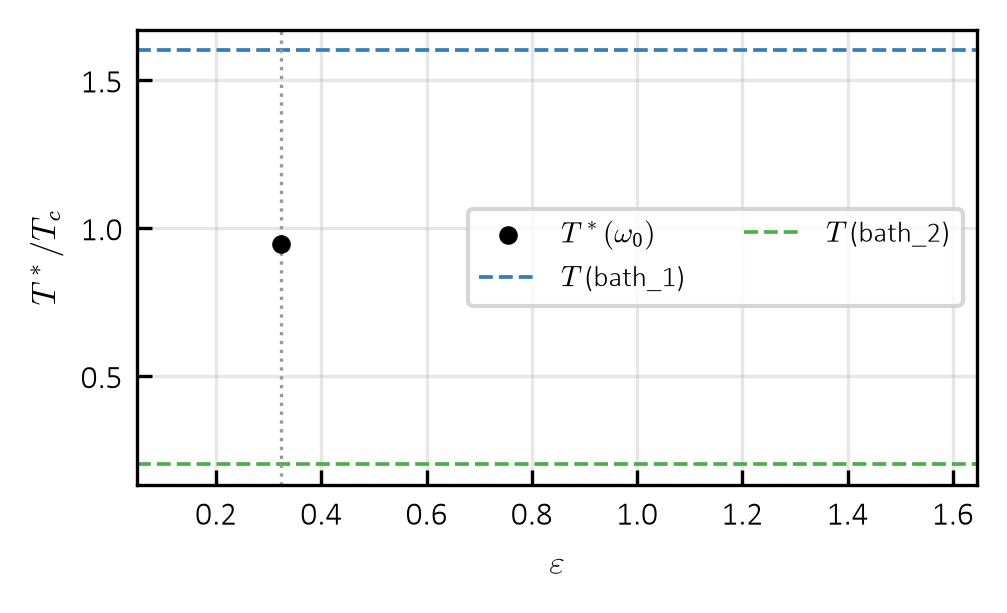

In [13]:
eg = np.linspace(0.05, 2.0 * w0 + 1.0, 600)


def t_star(eps, bb):
    ws = [bt.amp * (spec_line(np, eps, w0, bt.gam) if bt.gam > 0 else np.ones_like(eps))
          for bt in bb]
    nb = [1.0 / np.expm1(eps / bt.t) for bt in bb]
    nm = sum(w * n for w, n in zip(ws, nb)) / sum(ws)
    return eps / np.log1p(1.0 / nm)


ts0 = float(t_star(np.array([w0]), bs)[0])
with pt.figure(h=0.6) as fg:
    a = fg.ax
    if any(bt.gam > 0 for bt in bs):         # for gamma = 0 only T*(w0) exists
        a.plot(eg, t_star(eg, bs) / tc, color=SET1_LIST[0], lw=1.2,
               label=r"$T^*(\varepsilon)$")
    a.scatter([w0], [ts0 / tc], color="k", s=12, zorder=5, label=r"$T^*(\omega_0)$")
    for bt, c_ in zip(bs, SET1_LIST[1:3]):
        a.axhline(bt.t / tc, color=c_, ls="--", lw=0.9, label=rf"$T$ ({bt.name})")
    a.axvline(w0, color="0.6", ls=":", lw=0.8)
    format_ax(a, x=eg, xlabel=r"$\varepsilon$", ylabel=r"$T^*/T_c$")
    add_legend(a, ncol=2, fontsize=7)

## NESS occupations against Fermi-Dirac
Cell occupations n_nu(I) against their cell energies, with FD curves at
T1, T2 and T*(w0) (chemical potential of the equilibrium solver).

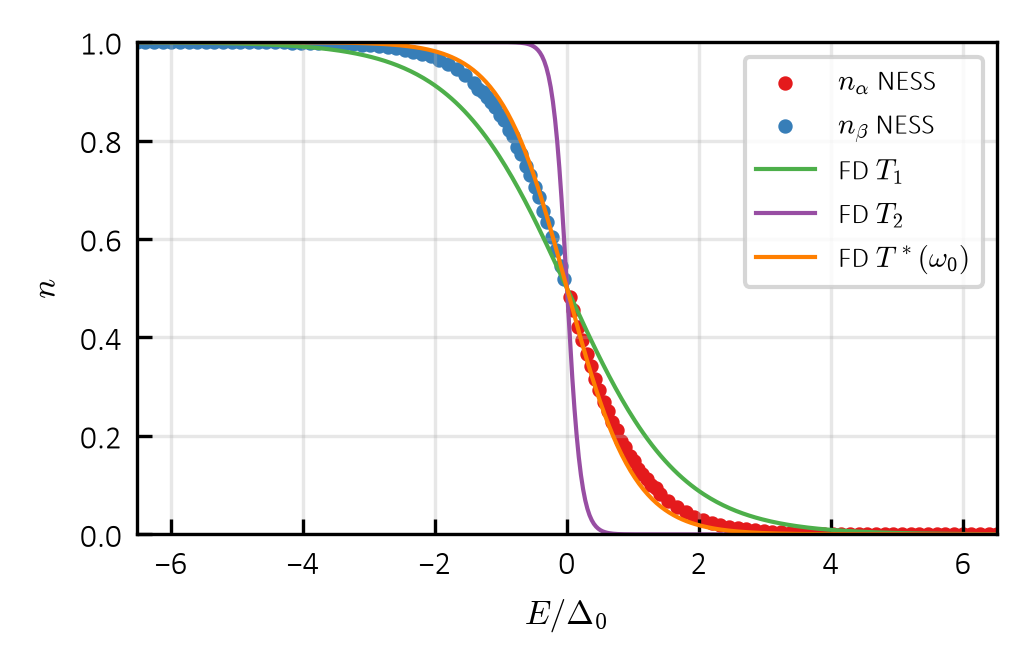

In [14]:
from EI_bins.eq import chem_pot

xe = np.linspace(so.e.min(), so.e.max(), 400)
with pt.figure(h=0.65) as fg:
    a = fg.ax
    for nu in range(2):
        a.scatter(so.e[nu] / d0, so.n[nu], s=6, color=SET1_LIST[nu],
                  label=rf"$n_{{{bl[nu]}}}$ NESS")
    for t_, lb_, c_ in ((t1, r"$T_1$", SET1_LIST[2]), (t2, r"$T_2$", SET1_LIST[3]),
                        (ts0, r"$T^*(\omega_0)$", SET1_LIST[4])):
        mc = chem_pot(so.e, sh.w, p.n, t_)
        a.plot(xe / d0, 1.0 / (np.exp((xe - mc) / t_) + 1.0), color=c_, lw=1.0,
               label=rf"FD {lb_}")
    format_ax(a, x=xe / d0, xlabel=r"$E/\Delta_0$", ylabel=r"$n$", ylim=(0.0, 1.0))
    add_legend(a, fontsize=7)

## Isotropy of the closure n(k) = n(s(k))
One Jacobi step of the k resolved rate equations from the NESS above:
each fine grid state keeps the momentum structure of |g(k - p)|^2, which
gives a local multiplier mu(k). Top: relative spread of the total rate of
the states in a cell. Bottom: spread of mu(k) - mu_I; the closure error of
the cell averages is second order in it.

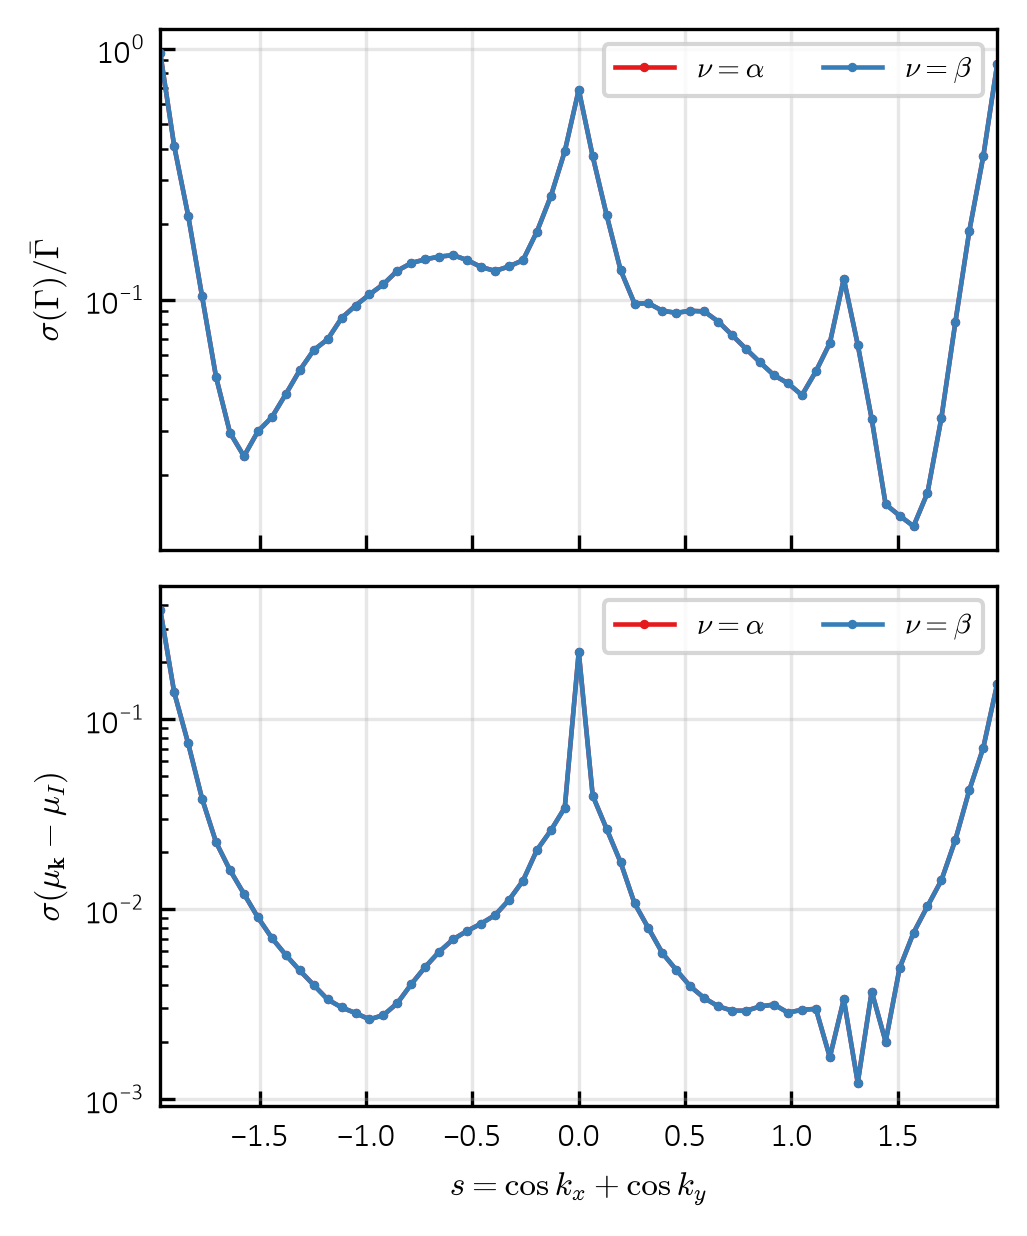

max |<n_k> - n_I|: 0.011033147410244859


In [15]:
from EI_bins.checks import check_iso

iso = check_iso(sh, bd, p, bs, so, A=kn)
with pt.figure(shape=(2, 1), h=1.2, sharex=True) as fg:
    for a, key, lab_ in zip(fg.ax, ("gam", "dmu"),
                            (r"$\sigma(\Gamma)/\bar\Gamma$", r"$\sigma(\mu_\mathbf{k}-\mu_I)$")):
        for nu in range(2):
            a.plot(sh.sc, iso[key][nu], color=SET1_LIST[nu], lw=1.1, marker=".", ms=2.5,
                   label=rf"$\nu={bl[nu]}$")
        a.set_yscale("log")
        format_ax(a, x=sh.sc, ylabel=lab_)
        add_legend(a, ncol=2, fontsize=7)
    fg.ax[-1].set_xlabel(r"$s=\cos k_x+\cos k_y$")
print("max |<n_k> - n_I|:", np.nanmax(np.abs(iso["dn"])))